In [83]:
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt
import os
import sys
sys.path.insert(0, '../scripts')
from plotting import *
#load_ext autoreload
#autoreload 2

#### Plots evaluation cell qualities for different reweightings of the Z+jet events

../plots/cells/had_beta1_cellevents


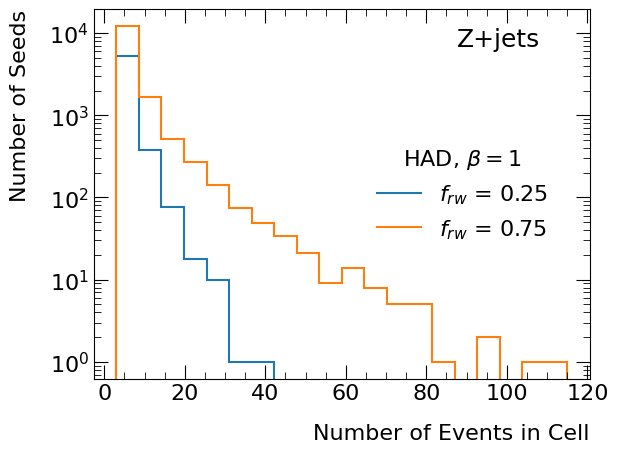

In [91]:
rwFracs = [0.25, 0.75]
path = "/oscar/data/mleblan6/lhay"
stage = "had"
if stage == "hp":
    stage_str = "HS"
    cell_pop_files = [path + "/cell_info/cell_pop_hp_6p5gev_b1.npy",
                      path + "/cell_info/cell_pop_hp_12p4gev_b1.npy"]
elif stage == "ps":
    stage_str = "PS"
    cell_pop_files = [path + "/cell_info/cell_pop_ps_8p9gev_b1.npy",
                      path + "/cell_info/cell_pop_ps_16p7gev_b1.npy"]
elif stage == "had":
    stage_str = "HAD"
    cell_pop_files = [path + "/cell_info/cell_pop_had_9p7gev_b1.npy",
                      path + "/cell_info/cell_pop_had_16p4gev_b1.npy"]
cell_pop_arrays = [np.load(f) for f in cell_pop_files]

# Find the global min/max for consistent binning
all_data = np.concatenate(cell_pop_arrays)
bins = np.linspace(np.min(all_data), np.max(all_data), 21)  # 20 bins

# Create histograms and plot
fig, ax = plt.subplots()

for data, frac in zip(cell_pop_arrays, rwFracs):
    counts, bin_edges = np.histogram(data, bins=bins)
    hep.histplot(counts, bin_edges, ax=ax, label=r"$f_{rw}$ = " + f'{frac}')
ax.text(0.9, 0.95, "Z+jets", transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=18)


ax.set_yscale("log")
configure_axis(ax, "Number of Events in Cell", "Number of Seeds")
ax.legend(title=rf"{stage_str}, $\beta=1$", frameon=False, fontsize=16, loc="center right", borderpad=1.4, title_fontsize=16)

directory = f"../plots/cells"
filename = stage + "_beta1_cellevents"
if not os.path.exists(directory):
    os.makedirs(directory)
print(f"{directory}/{filename}")
plt.savefig(f"{directory}/{filename}.pdf", bbox_inches='tight')

plt.show()


../plots/cells/had_beta1_cellradii


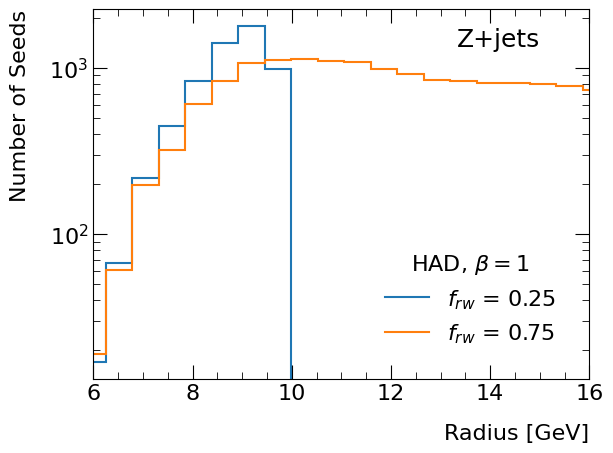

In [92]:
rwFracs = [0.25, 0.75]
if stage == "hp":
    stage_str = "HS"
    cell_pop_files = [path + "/cell_info/cell_radius_hp_6p5gev_b1.npy",
                      path + "/cell_info/cell_radius_hp_12p4gev_b1.npy"]
elif stage == "ps":
    stage_str = "PS"
    cell_pop_files = [path + "/cell_info/cell_radius_ps_8p9gev_b1.npy",
                      path + "/cell_info/cell_radius_ps_16p7gev_b1.npy"]
elif stage == "had":
    stage_str = "HAD"
    cell_pop_files = [path + "/cell_info/cell_radius_had_9p7gev_b1.npy",
                      path + "/cell_info/cell_radius_had_16p4gev_b1.npy"]

cell_pop_arrays = [np.load(f) for f in cell_pop_files]

# Find the global min/max for consistent binning
all_data = np.concatenate(cell_pop_arrays)
bins = np.linspace(np.min(all_data), np.max(all_data), 21)  # 20 bins

# Create histograms and plot
fig, ax = plt.subplots()

for data, frac in zip(cell_pop_arrays, rwFracs):
    counts, bin_edges = np.histogram(data, bins=bins)
    hep.histplot(counts, bin_edges, ax=ax, label=r"$f_{rw}$ = " + f'{frac}')

ax.set_yscale("log")
configure_axis(ax, "Radius [GeV]", "Number of Seeds")
ax.legend(title=rf"{stage_str}, $\beta=1$", frameon=False, fontsize=16, loc="lower right", borderpad=1.0, title_fontsize=16)
ax.set_xlim(6, 16)

ax.text(0.9, 0.95, "Z+jets", transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=18)

directory = f"../plots/cells"
filename = stage + "_beta1_cellradii"
if not os.path.exists(directory):
    os.makedirs(directory)
print(f"{directory}/{filename}")
plt.savefig(f"{directory}/{filename}.pdf", bbox_inches='tight')

plt.show()



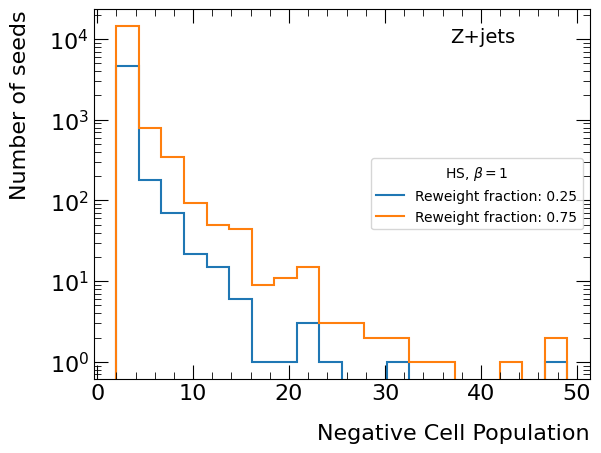

In [79]:
rwFracs = [0.25, 0.75]
stage = "hp"
if stage == "hp":
    stage_str = "HS"
    cell_pop_files = [path + "/cell_info/neg_cell_pop_hp_6p5gev_b1.npy",
                      path + "/cell_info/neg_cell_pop_hp_12p4gev_b1.npy"]
elif stage == "ps":
    stage_str = "PS"
    cell_pop_files = [path + "/cell_info/neg_cell_pop_ps_8p9gev_b1.npy",
                      path + "/cell_info/neg_cell_pop_ps_16p7gev_b1.npy"]
elif stage == "had":
    stage_str = "HAD"
    cell_pop_files = [path + "/cell_info/neg_cell_pop_had_9p7gev_b1.npy",
                      "/cell_info/neg_cell_pop_had_16p4gev_b1.npy"]
cell_pop_arrays = [np.load(f) for f in cell_pop_files]

# Find the global min/max for consistent binning
all_data = np.concatenate(cell_pop_arrays)
bins = np.linspace(np.min(all_data), np.max(all_data), 21)  # 20 bins

# Create histograms and plot
fig, ax = plt.subplots()

ax.text(0.85, 0.95, "Z+jets", transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=14)

for data, frac in zip(cell_pop_arrays, rwFracs):
    counts, bin_edges = np.histogram(data, bins=bins)
    hep.histplot(counts, bin_edges, ax=ax, label=f'Reweight fraction: {frac}')
ax.set_yscale("log")
configure_axis(ax, "Negative Cell Population", "Number of seeds")
ax.legend(title=rf"{stage_str}, $\beta=1$")
plt.show()
